# Modelling Trade Arrivals as a Poisson Process

I'm currently covering Poisson distributions in my stats class and wanted to 
see how the theory holds up on real market data. The idea is simple; if trades 
arrive randomly and independently, the number of trades in a fixed time window 
should follow a Poisson distribution.

I'm using BTC/USDT on Binance as the test case. It's one of the most liquid 
pairs in the world, so there's no shortage of data.

## Step 1: Fetching the Data

Binance has a public API that doesn't require any authentication. 
I'm grabbing the 1000 most recent BTC/USDT trades and pulling out 
the price, quantity, and timestamp for each one.

In [2]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import poisson, chi2

In [3]:
def fetch_trades(symbol, limit=1000):
    url = 'https://api.binance.com/api/v3/trades'
    params = {'symbol': symbol, 'limit': limit}
    response = requests.get(url, params=params, timeout=10)
    return response.json()

trades = fetch_trades('BTCUSDT')
print(f'Trades fetched: {len(trades)}')

Trades fetched: 1000


In [4]:
df = pd.DataFrame(trades)[['price', 'qty', 'time']]
df['price'] = df['price'].astype(float)
df['qty'] = df['qty'].astype(float)
df['time'] = pd.to_datetime(df['time'], unit='ms')

df.head()

,price,qty,time
0,77105.25,0.00007,2026-05-21 16:53:18.565
1,77105.25,0.00007,2026-05-21 16:53:18.565
2,77105.25,0.00007,2026-05-21 16:53:18.565
3,77105.25,0.00007,2026-05-21 16:53:18.565
4,77105.25,0.00007,2026-05-21 16:53:18.565


## Step 2: Binning Trades into 1-Second Windows

To use the Poisson distribution, I need to count how many trades 
happen in each fixed time window. I'm using 1-second windows.

The key thing here is filling in the empty seconds with zeros.
If no trades happened in a window it still needs to be counted.

In [5]:
df['second'] = df['time'].dt.floor('s')
counts = df.groupby('second').size()

In [6]:
all_seconds = pd.date_range(
    start=df['time'].min().floor('s'),
    end=df['time'].max().floor('s'),
    freq='s'
)

counts = counts.reindex(all_seconds, fill_value=0)
print(f'Total windows: {len(counts)}')
print(f'Zero-trade windows: {(counts == 0).sum()}')
print(f'Average trades per second: {counts.mean():.2f}')
print(f'Max trades in one second: {counts.max()}')

Total windows: 62
Zero-trade windows: 11
Average trades per second: 16.13
Max trades in one second: 205


## Step 3: Estimating Lambda

Lambda (λ) is the average number of trades per window. In a Poisson 
distribution, Var(X) or the variance should equal the mean, so a variance-to-mean 
ratio close to 1 means the data fits well. Anything much higher than 1 
means trades are clustering, which is called overdispersion.

In [7]:
lambda_hat = counts.mean()
dispersion = counts.var() / lambda_hat

print(f'Lambda: {lambda_hat:.4f} trades/second')
print(f'Variance-to-mean ratio: {dispersion:.4f}')

Lambda: 16.1290 trades/second
Variance-to-mean ratio: 89.2464


A ratio close to 1 means the data fits Poisson well. 
Anything much higher means trades are clustering. These are the bursts 
you'd expect to see when a big order hits the market or the 
price moves sharply.

## Step 4: Visualising the Distribution

I plotted two charts. The one to the compares the empirical distribution 
to what a Poisson distribution with the same lambda would look like. 
The right one shows the trade counts over time so you can actually 
see the clustering.

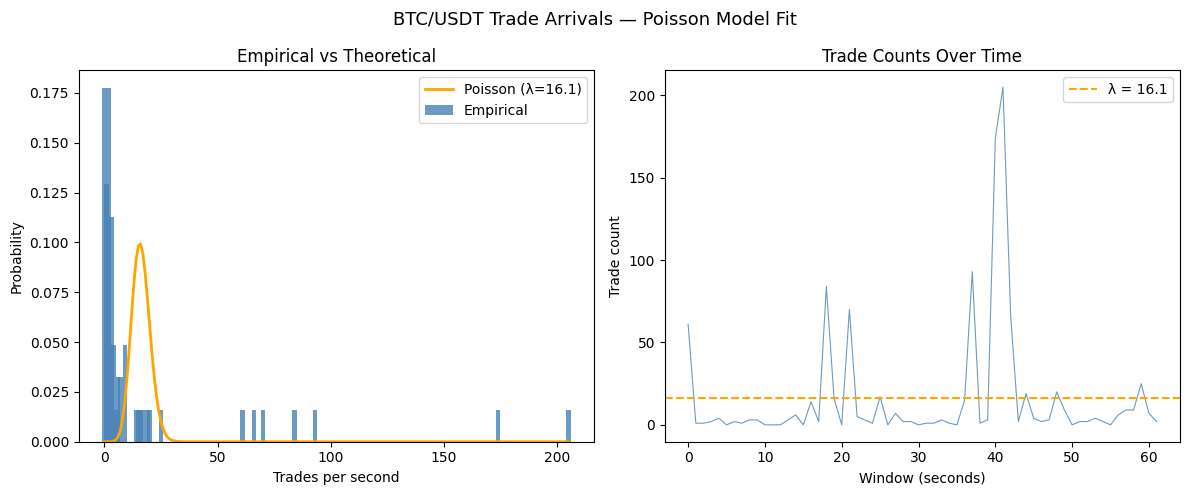

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('BTC/USDT Trade Arrivals — Poisson Model Fit', fontsize=13)

observed_probs = counts.value_counts().sort_index() / len(counts)
k_vals = np.arange(0, counts.max() + 1)
theoretical_probs = poisson.pmf(k_vals, mu=lambda_hat)

axes[0].bar(observed_probs.index, observed_probs.values, width=2, 
            label='Empirical', alpha=0.8, color='steelblue')
axes[0].plot(k_vals, theoretical_probs, color='orange', linewidth=2, 
             label=f'Poisson (λ={lambda_hat:.1f})')
axes[0].set_xlabel('Trades per second')
axes[0].set_ylabel('Probability')
axes[0].set_title('Empirical vs Theoretical')
axes[0].legend()

axes[1].plot(counts.values, color='steelblue', linewidth=0.8, alpha=0.8)
axes[1].axhline(lambda_hat, color='orange', linestyle='--', 
                linewidth=1.5, label=f'λ = {lambda_hat:.1f}')
axes[1].set_xlabel('Window (seconds)')
axes[1].set_ylabel('Trade count')
axes[1].set_title('Trade Counts Over Time')
axes[1].legend()

plt.tight_layout()
plt.show()

## Conclusion

The Poisson model doesn't fit BTC/USDT trade arrivals well, at least 
not at the 1-second level. The variance-to-mean ratio is way above 1 
and the plots make it veryt obvious. We can see most seconds are quiet but every so 
often there's a burst of hundreds of trades in a single second.

This makes sense intuitively. Trades on a liquid exchange aren't 
independent random events; they react to price moves, large orders, 
and other trades. The Poisson assumption of a constant arrival rate 
just doesn't hold in practice.

A natural next step would be to look at a less liquid pair or a wider 
time window to see if the fit improves, or to try a Negative Binomial 
distribution which relaxes the variance = mean constraint.